In [1]:
 import numpy as np
from decimal import Decimal
from matplotlib import pyplot as plt, cm
import matplotlib.gridspec as gridspec
from matplotlib import colormaps as colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
import lenstronomy.Util.image_util as image_util
from matplotlib_scalebar.scalebar import ScaleBar    
import numpy as np
from skimage.transform import resize
import jax

ModuleNotFoundError: No module named 'matplotlib_scalebar'

In [3]:
import lenstronomy
print("Lenstronomy version:", lenstronomy.__version__)
import gigalens
import astropy

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

# make sure lenstronomy is installed, otherwise install the latest pip version
try:
    import lenstronomy
except:
    !pip install lenstronomy

import lenstronomy.Util.simulation_util as sim_util
import lenstronomy.Util.image_util as image_util
from lenstronomy.Util import param_util
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Sampling.parameters import Param
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from astropy.io import fits

import gigalens
import tensorflow_probability.substrates.jax as tfp
from corner import corner
from scipy.stats import norm

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear, sie, tnfw

tfd = tfp.distributions

import jax
from jax import numpy as jnp

Lenstronomy version: 1.12.3


In [7]:
kernel = np.load('/global/u2/a/aharsh/gigalens/src/gigalens/assets/psf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.03, num_pix=125, supersample=2, kernel=kernel2)

# NFW

phys_model = PhysicalModel([tnfw.TNFW(), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)

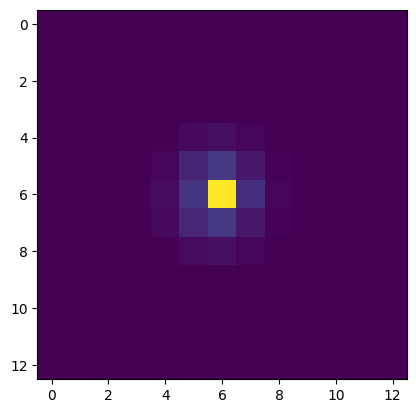

In [5]:
plt.imshow(kernel)

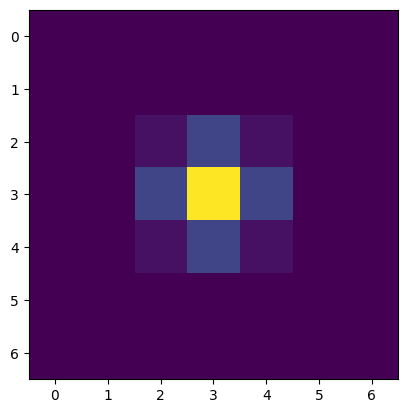

In [5]:
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.Data.psf import PSF
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel

kwargs_psf = {'psf_type': 'GAUSSIAN',  # type of PSF model (supports 'GAUSSIAN' and 'PIXEL')
              'fwhm': 0.04,  # full width at half maximum of the Gaussian PSF (in angular units)
              'pixel_size': 0.03  # angular scale of a pixel (required for a Gaussian PSF to translate the FWHM into a pixel scale)
             }

psf = PSF(**kwargs_psf)
kernel2 = psf.kernel_point_source
plt.imshow(kernel2)

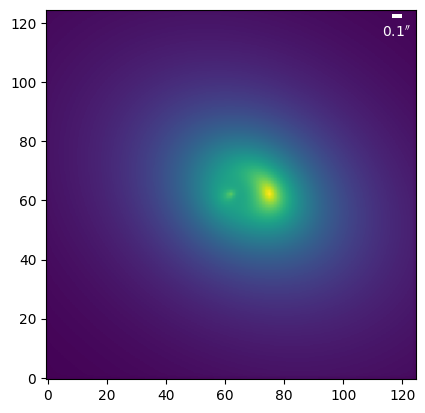

In [9]:
# CURRENTLY SHOWING WITH KERNEL2 w/ lenstronomy bc wanted to perform comparison
# use variable kernel to get original version, not too different though

lens_light_params = [{'R_sersic': 0.1, 'n_sersic': 2, 'e1': 0.1, 'e2': 0.2, 'center_x': 0, 'center_y': 0, 'Ie': 20}]
source_light_params = [{'R_sersic': 1.5, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.15, 'center_x': 0.2, 'center_y': 0, 'Ie': 70}
]
lens_params = [{'Rs': 0.7, 'alpha_Rs': 0.2, 'r_trunc': 10, 'center_x': 0, 'center_y': 0}, {'gamma1': 0.02, 'gamma2': 0.01}]

test_full = lens_sim.simulate((lens_params, lens_light_params, source_light_params))
from matplotlib_scalebar.scalebar import ScaleBar
fig, ax = plt.subplots()
ax.imshow(test_full)
ax.invert_yaxis()
scalebar = ScaleBar(
        0.03, # deltaPix
        units="\'\'",
        dimension="angle",
        frameon=False,
        fixed_value=0.1, 
        color="white"
)
ax.add_artist(scalebar)
plt.show()

In [10]:
lens_model_list = ['TNFW', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list)
source_light_model_list = ['SERSIC_ELLIPSE']
lightModel_source = LightModel(light_model_list=source_light_model_list)
lens_light_model_list = ['SERSIC_ELLIPSE']
lightModel_lens = LightModel(light_model_list=lens_light_model_list)

kwargs_numerics = {'supersampling_factor': 2, # each pixel gets super-sampled (in each axis direction) 
                  'supersampling_convolution': False}

deltaPix = 0.03

nx = ny = 125
deltaPix = 0.03

# RA/DEC of the *first* pixel centre
ra_at_xy_0  = -0.5 * nx * deltaPix     #  = -1.8
dec_at_xy_0 = -0.5 * ny * deltaPix

transform_pix2angle = np.array([[deltaPix, 0],
                                [0,        deltaPix]])

kwargs_pixel = dict(nx=nx, ny=ny,
                    ra_at_xy_0=ra_at_xy_0,
                    dec_at_xy_0=dec_at_xy_0,
                    transform_pix2angle=transform_pix2angle)
pixel_grid   = PixelGrid(**kwargs_pixel)

imageModel = ImageModel(data_class=pixel_grid, psf_class=psf, lens_model_class=lensModel,
                        source_model_class=lightModel_source,
                        lens_light_model_class=lightModel_lens,
                        point_source_class=None, # in this example, we do not simulate point source.
                        kwargs_numerics=kwargs_numerics)

In [11]:
lens_light_params = [{'R_sersic': 0.1, 'n_sersic': 2, 'e1': 0.1, 'e2': 0.2, 'center_x': 0, 'center_y': 0, 'Ie': 20}]
source_light_params = [{'R_sersic': 1.5, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.15, 'center_x': 0.2, 'center_y': 0, 'Ie': 70}
]
lens_params = [{'Rs': 0.7, 'alpha_Rs': 0.2, 'r_trunc': 10, 'center_x': 0, 'center_y': 0}, {'gamma1': 0.02, 'gamma2': 0.01}]


kwargs_lens = [
    {'Rs': 0.7, 
     'alpha_Rs': 0.2,
     'r_trunc': 10, 
     'center_x': 0, 
     'center_y': 0},
    {'gamma1': 0.02, 
     'gamma2': 0.01}]

kwargs_light_lens = [{'R_sersic': 0.1, 'n_sersic': 3, 
                      'e1': 0.1, 'e2': 0.2, 'center_x': 0, 'center_y': 0, 'amp': 20}]
kwargs_light_source = [{'R_sersic': 1.5, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.15,
                        'center_x': 0.2, 'center_y': 0, 'amp': 70}
]

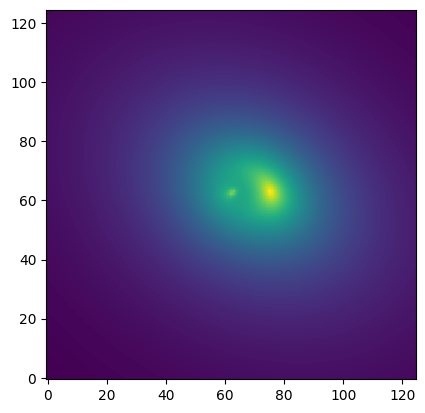

In [12]:
image = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_light_source,
                         kwargs_lens_light=kwargs_light_lens)
plt.imshow(image, origin='lower')

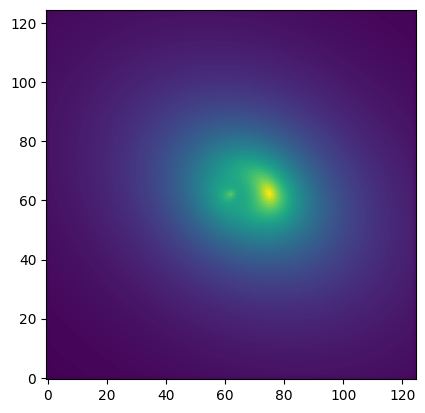

In [13]:
plt.imshow(test_full, origin='lower')

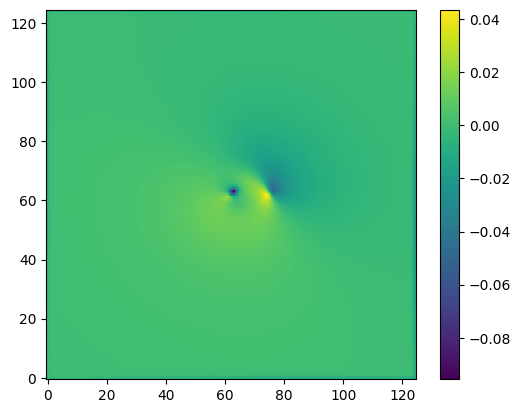

In [14]:
plt.imshow(test_full-image, origin='lower')
plt.colorbar()

In [15]:
import numpy as np
from scipy.optimize import brentq
from lenstronomy.LensModel.lens_model import LensModel

# Define the lens model list for a TNFW profile.
lens_model_list = ['TNFW']

# Your lens parameters for the TNFW profile:
kwargs_lens = [{
    'Rs': 0.7,
    'alpha_Rs': 0.2,
    'r_trunc': 10,
    'center_x': 0,
    'center_y': 0
}]

# Create an instance of the LensModel class.
lensModel = LensModel(lens_model_list=lens_model_list)

# Define the equation for the Einstein radius.
def einstein_eq(r):
    # Evaluate the x-component of the deflection at (r, 0) using the lens parameters.
    # The alpha() method expects the x and y positions as separate arguments.
    alpha = lensModel.alpha(r, 0, kwargs=kwargs_lens)[0]  # extract the x-component of deflection
    return r - alpha

# Use SciPy's brentq to solve for r such that einstein_eq(r) = 0.
r_min, r_max = 0.01, 5.0  # Adjust the bracket limits as needed.
r_einstein = brentq(einstein_eq, r_min, r_max)
print("Einstein radius:", r_einstein)


Einstein radius: 0.10148688105999586


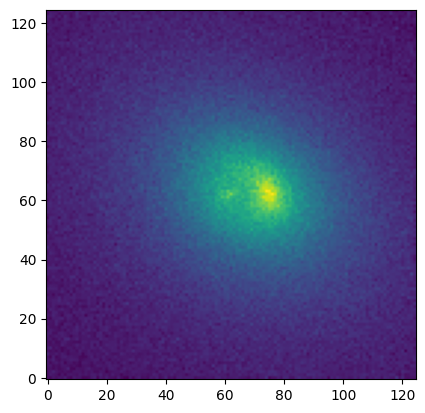

In [16]:
obs = test_full
# adding noise
import lenstronomy.Util.image_util as image_util
exp_time = 1200  
background_rms = 1.615479000000E-02 
poisson = image_util.add_poisson(obs, exp_time=exp_time)
bkg = image_util.add_background(obs,sigma_bkd=background_rms) 
observed_img = obs + bkg + poisson
plt.imshow(observed_img, origin='lower')
plt.show()

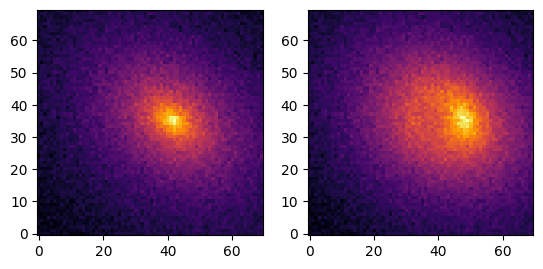

In [17]:
unlens = lens_sim.simulate(([], [], source_light_params)) + poisson + bkg
lensed = lens_sim.simulate((lens_params, [], source_light_params)) + poisson + bkg
fig, plts = plt.subplots(1, 2)
plts[0].imshow(unlens[125//2-35:125//2+35,125//2-35:125//2+35], cmap='inferno', origin='lower')
plts[1].imshow(lensed[125//2-35:125//2+35,125//2-35:125//2+35], cmap='inferno', origin='lower')

In [18]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                Rs=tfd.LogNormal(jnp.log(1), 0.15), 
                alpha_Rs=tfd.TruncatedNormal(0.3, 0.1, 0.05, 0.55),
                r_trunc = tfd.Normal(12, 5),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.1), 0.25),
                n_sersic=tfd.Uniform(0.5, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                Ie=tfd.LogNormal(jnp.log(30), 0.3),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.5), 0.15),
                n_sersic=tfd.Uniform(0.5, 6),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(70), 0.5), # look at pixel values in arcs
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [19]:
sim_config = SimulatorConfig(delta_pix=0.03, num_pix=125, supersample = 2, kernel=kernel)
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=1200)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [20]:
import optax

fitter = ModellingSequence(phys_model, prob_model, sim_config)
schedule_fn = optax.polynomial_schedule(init_value=-1e-2, end_value=-1e-2/2, 
                                      power=0.5, transition_steps=750)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP(opt, n_samples=950, num_steps=1000, seed=0)

  0%|          | 0/1000 [00:00<?, ?it/s]

2025-09-23 11:23:30.447440: E external/xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng38{k2=4,k13=0,k14=2,k18=1,k22=2,k23=0} for conv (f32[237,1,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[237,1,250,250]{3,2,1,0}, f32[1,1,25,25]{3,2,1,0}), window={size=25x25 pad=12_12x12_12}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-09-23 11:23:30.477717: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.030466626s
Trying algorithm eng38{k2=4,k13=0,k14=2,k18=1,k22=2,k23=0} for conv (f32[237,1,250,250]{3,2,1,0}, u8[0]{0}) custom-call(f32[237,1,250,250]{3,2,1,0}, f32[1,1,25,25]{3,2,1,0}), window={size=25x25 pad=12_12x12_12}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convFor

TypeError: Only scalar arrays can be converted to Python scalars; got arr.ndim=1

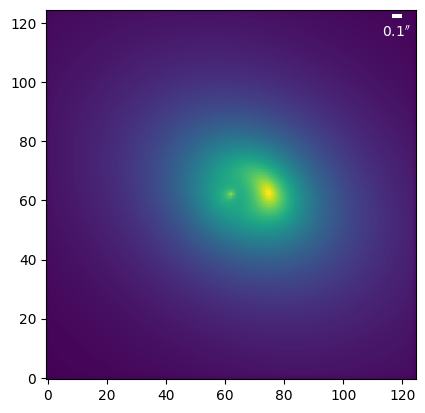

In [60]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=948), map_estimate)[0]
best = map_estimate[jnp.nanargmax(lps)][jnp.newaxis,:]
mapimg = prob_model.bij.forward(list(best.T)) # best MAP Img
sim = lens_sim.simulate(mapimg)
fig, ax = plt.subplots()
ax.imshow(sim)
ax.invert_yaxis()
scalebar = ScaleBar(
        0.03,
        units="\'\'",
        dimension="angle",
        frameon=False,
        fixed_value=0.1,
        color="white"
)
ax.add_artist(scalebar)
plt.show()

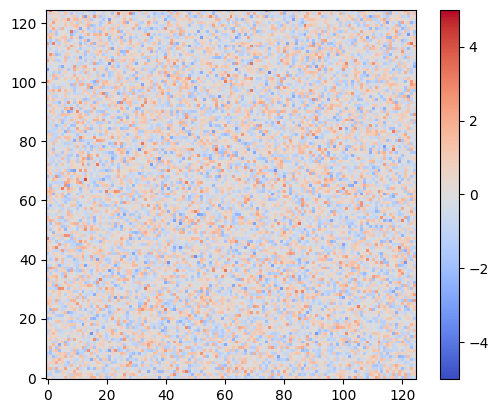

In [61]:
err_map = np.sqrt(background_rms**2+sim/1200)
observed_img2 = observed_img.astype(np.float32)
resid = sim - observed_img2
plt.imshow(resid/err_map, cmap='coolwarm', interpolation='none', vmin=-5, vmax=5, origin='lower')
plt.colorbar()

In [62]:
print('Chi-square:', np.mean((resid/err_map)**2))
prob_model.bij.forward(list(best.T))

Chi-square: 1.0045217


[[{'r_trunc': Array([10.98225], dtype=float32),
   'center_y': Array([-0.01795539], dtype=float32),
   'center_x': Array([-0.0053102], dtype=float32),
   'alpha_Rs': Array([0.19145615], dtype=float32),
   'Rs': Array([0.6342867], dtype=float32)},
  {'gamma2': Array([-0.0027578], dtype=float32),
   'gamma1': Array([0.02645659], dtype=float32)}],
 [{'n_sersic': Array([3.546149], dtype=float32),
   'e2': Array([0.08259407], dtype=float32),
   'e1': Array([0.09076607], dtype=float32),
   'center_y': Array([-0.00110803], dtype=float32),
   'center_x': Array([0.00098852], dtype=float32),
   'R_sersic': Array([0.08396714], dtype=float32),
   'Ie': Array([24.371542], dtype=float32)}],
 [{'n_sersic': Array([1.4804401], dtype=float32),
   'e2': Array([-0.13228321], dtype=float32),
   'e1': Array([0.04197463], dtype=float32),
   'center_y': Array([-9.993779e-05], dtype=float32),
   'center_x': Array([0.19917552], dtype=float32),
   'R_sersic': Array([1.4776026], dtype=float32),
   'Ie': Array([72

  0%|          | 0/2400 [00:00<?, ?it/s]

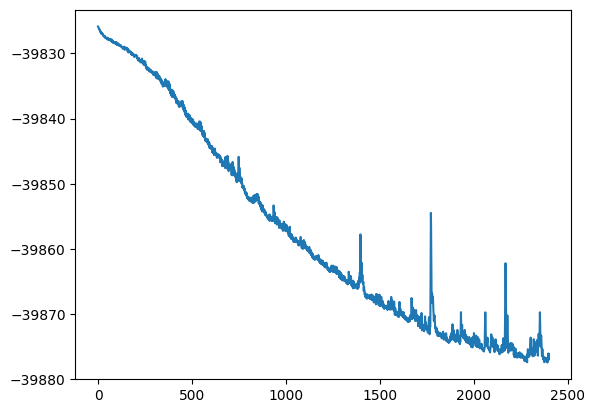

In [14]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-6*5, end_value=-3e-3, 
                                      power=2, transition_steps=750)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1500, num_steps=2400)
plt.plot(loss_hist)

In [15]:
samples = fitter.HMC(qz, n_hmc=50, init_eps=0.3, init_l=3, max_leapfrog_steps=150,
                                   num_burnin_steps=950, num_results=2000)
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)
prob_model.pack_bij.forward(list(rhat))

Sampling took 236.0s


[[{'r_trunc': Array(1.0958945, dtype=float32),
   'center_y': Array(1.001456, dtype=float32),
   'center_x': Array(1.0075426, dtype=float32),
   'alpha_Rs': Array(1.0052762, dtype=float32),
   'Rs': Array(1.0148777, dtype=float32)},
  {'gamma2': Array(1.0129426, dtype=float32),
   'gamma1': Array(1.0052848, dtype=float32)}],
 [{'n_sersic': Array(1.0020725, dtype=float32),
   'e2': Array(1.0014423, dtype=float32),
   'e1': Array(1.0050484, dtype=float32),
   'center_y': Array(1.0105487, dtype=float32),
   'center_x': Array(1.0025309, dtype=float32),
   'R_sersic': Array(1.0016025, dtype=float32),
   'Ie': Array(1.0033852, dtype=float32)}],
 [{'n_sersic': Array(1.2346376, dtype=float32),
   'e2': Array(1.009368, dtype=float32),
   'e1': Array(1.0151739, dtype=float32),
   'center_y': Array(1.0210471, dtype=float32),
   'center_x': Array(1.1000478, dtype=float32),
   'R_sersic': Array(1.0124227, dtype=float32),
   'Ie': Array(1.2017725, dtype=float32)}]]

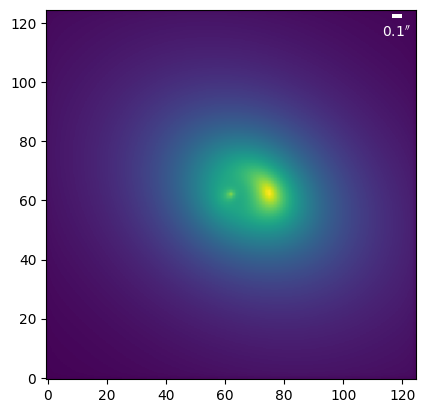

In [16]:
smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, 21))
best = prob_model.bij.forward(list(np.median(smp,axis=0)))

fig, ax = plt.subplots()
simulated = lens_sim.simulate(best)
scalebar = ScaleBar(
        0.03,
        units="\'\'",
        dimension="angle",
        frameon=False,
        fixed_value=0.1,
        color="white"
)
ax.add_artist(scalebar)
ax.imshow(simulated)
ax.invert_yaxis()
plt.show()


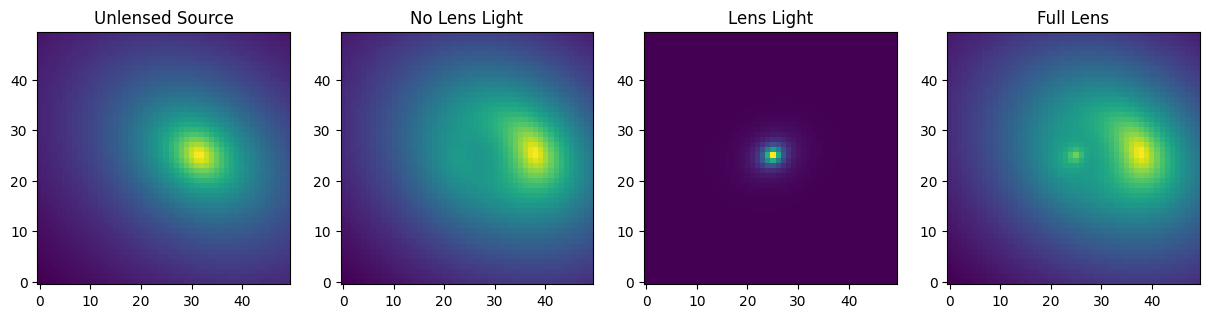

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15,15))

ax[0].imshow(lens_sim.simulate(([], [], best[2]))[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower')
ax[0].set_title("Unlensed Source")
ax[1].imshow(lens_sim.simulate((best[0], [], best[2]))[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower')
ax[1].set_title("No Lens Light")
ax[2].imshow(lens_sim.simulate(([], best[1], []))[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower')
ax[2].set_title("Lens Light")
ax[3].imshow(lens_sim.simulate(best)[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower')
ax[3].set_title("Full Lens")
plt.show()

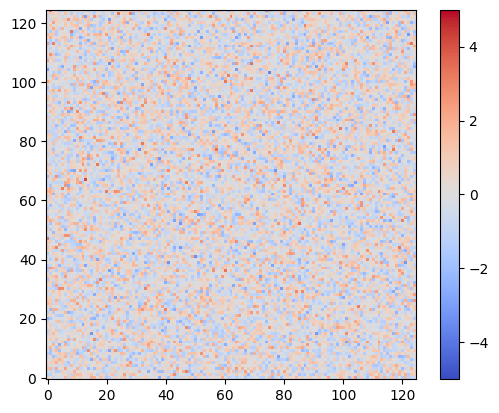

In [18]:
err_map = np.sqrt(background_rms**2+simulated/exp_time)
observed_img2 = observed_img.astype(np.float32)
resid = simulated - observed_img2
plt.imshow(resid/err_map, cmap='coolwarm', interpolation='none', vmin=-5, vmax=5, origin='lower')
plt.colorbar()

In [19]:
print('Chi-square:', np.mean((resid/err_map)**2))
best

Chi-square: 1.0042616


[[{'r_trunc': Array(11.7041235, dtype=float32),
   'center_y': Array(-0.01672971, dtype=float32),
   'center_x': Array(-0.00201925, dtype=float32),
   'alpha_Rs': Array(0.20214914, dtype=float32),
   'Rs': Array(0.70560664, dtype=float32)},
  {'gamma2': Array(-0.00227068, dtype=float32),
   'gamma1': Array(0.02088537, dtype=float32)}],
 [{'n_sersic': Array(2.9381354, dtype=float32),
   'e2': Array(0.09060788, dtype=float32),
   'e1': Array(0.10220721, dtype=float32),
   'center_y': Array(-0.00151046, dtype=float32),
   'center_x': Array(0.00032939, dtype=float32),
   'R_sersic': Array(0.08503844, dtype=float32),
   'Ie': Array(25.114548, dtype=float32)}],
 [{'n_sersic': Array(1.4977432, dtype=float32),
   'e2': Array(-0.13385099, dtype=float32),
   'e1': Array(0.04924026, dtype=float32),
   'center_y': Array(-0.00037705, dtype=float32),
   'center_x': Array(0.19877912, dtype=float32),
   'R_sersic': Array(1.4909532, dtype=float32),
   'Ie': Array(70.44553, dtype=float32)}]]

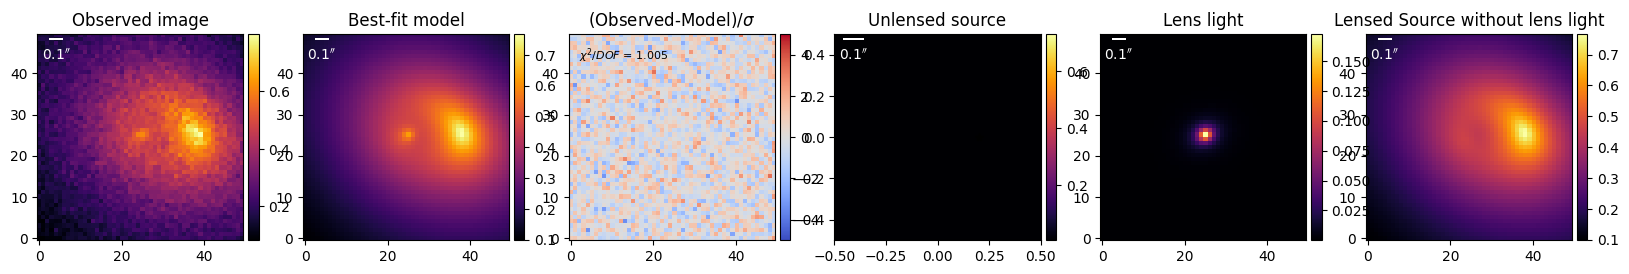

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(20, 16))  # Increased width for 6 images

no_ll = lens_sim.simulate((best[0], [], best[2]))

source = lens_sim.simulate(([], [], best[2]))

scalebar2 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar3 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar4 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar5 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
ax[0].add_artist(scalebar2)
ax[1].add_artist(scalebar3)
ax[4].add_artist(scalebar4)
ax[5].add_artist(scalebar5)

# Function to add colorbars
def add_colorbar(im, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    return fig.colorbar(im, cax=cax)

# Observed/Simulated Image
ax[0].set_title("Observed image")
im1 = ax[0].imshow(observed_img[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im1, ax[0])

# Modeled Image
ax[1].set_title("Best-fit model")
im2 = ax[1].imshow(simulated[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im2, ax[1])

# HMC Residuals
ax[2].set_title(r'(Observed-Model)/$\sigma$')
im3 = ax[2].imshow((resid/err_map)[125//2-25:125//2+25, 125//2-25:125//2+25],
                    cmap='coolwarm', interpolation='none', vmin=-5, vmax=5, origin='lower')
add_colorbar(im3, ax[2])
ax[2].text(2, 42, r'$\chi^2/DOF$ = 1.005', fontsize=8, ha='left', va='bottom')

# Unlensed Source W/ Caustic
ax[3].set_title("Unlensed source")
im5 = ax[3].imshow(source, origin='lower', cmap='inferno')
add_colorbar(im5, ax[3])

# lens_plot.caustics_plot(ax[3], data, lens_model, kwargs_lens,
#                         fast_caustic=False, color_crit='green', color_caustic='green', alpha=0.6)

scalebar = ScaleBar(1, units="\'\'", dimension="angle",
                    frameon=False, fixed_value=0.1, color="white", location='upper left')
ax[3].add_artist(scalebar)

x_coord = best[2][0]['center_x'].item()
y_coord = best[2][0]['center_y'].item()
ax[3].plot(x_coord, y_coord, '*', color='black', label='Source Center')
#ax[3].legend(fontsize='x-small')
ax[3].set_xlim(-0.5, 0.5)
ax[3].set_ylim(-0.5, 0.5)

# Simulated Lens Light
ax[4].set_title("Lens light")
im5 = ax[4].imshow(lens_sim.simulate(([], best[1], []))[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im5, ax[4])

# Lensed Image W/O Lens Light
ax[5].set_title("Lensed Source without lens light")
im6 = ax[5].imshow(no_ll[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im6, ax[5])

# Remove axes borders
# for i in ax.ravel():
#     i.set_axis_off()

plt.savefig("plot.png", dpi=300, bbox_inches="tight")
plt.show()


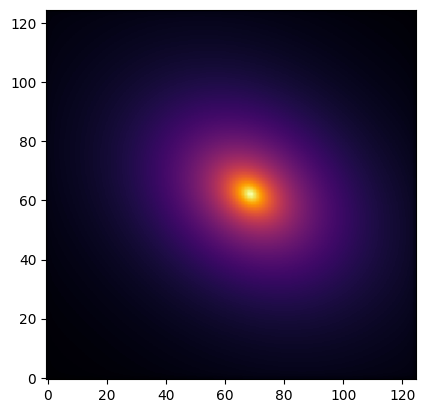

In [21]:
plt.imshow(source, origin='lower', cmap='inferno')

In [22]:
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
import lenstronomy.Util.simulation_util as sim_util
from lenstronomy.Data.imaging_data import ImageData
import lenstronomy.LensModel.lens_model as lens

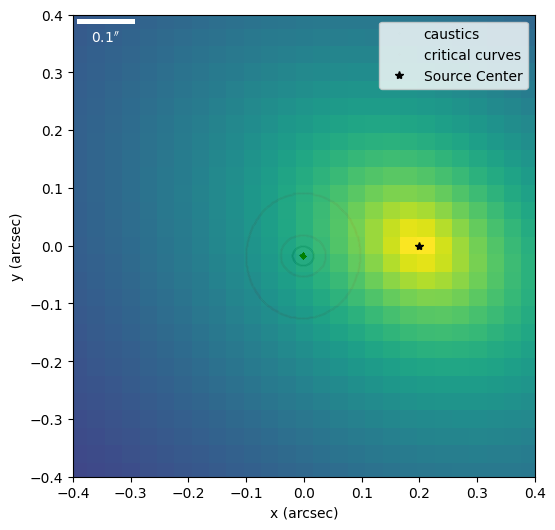

In [23]:
num_pix = 125
delta_pix = 0.03 

lens_model_list = ['TNFW', 'SHEAR']
lens_model = LensModel(lens_model_list=lens_model_list)

kwargs_data = sim_util.data_configure_simple(
    num_pix, delta_pix,
    center_ra=best[2][0]['center_x'].item(),
    center_dec=best[2][0]['center_y'].item(),
)

kwargs_main_lens = {
    'Rs': best[0][0]['Rs'].item(),
    'alpha_Rs': best[0][0]['alpha_Rs'].item(),
    'r_trunc': best[0][0]['r_trunc'].item(),
    'center_x': best[0][0]['center_x'].item(),
    'center_y': best[0][0]['center_y'].item(),
}

kwargs_shear = {
    'gamma1': best[0][1]['gamma1'].item(),
    'gamma2': best[0][1]['gamma2'].item(),
}

data = ImageData(**kwargs_data)

kwargs_lens = [kwargs_main_lens, kwargs_shear]

fig, ax = plt.subplots(figsize=(6, 6))

source = lens_sim.simulate(([], [], best[2]))

# change simulated parameter below to source if you want source plane image

ax.imshow(source, origin='lower', extent=[
    -num_pix * delta_pix / 2, num_pix * delta_pix / 2,
    -num_pix * delta_pix / 2, num_pix * delta_pix / 2
])

lens_plot.caustics_plot(
    ax, data, lens_model, kwargs_lens, 
    fast_caustic=False, 
    color_crit='red', 
    color_caustic='green', 
    alpha=0.6,
)

x_coord = best[2][0]['center_x'].item()
y_coord = best[2][0]['center_y'].item()
ax.plot(x_coord, y_coord, '*', color='black', label='Source Center')
scalebar = ScaleBar(
        1,
        units="\'\'",
        dimension="angle",
        frameon=False,
        fixed_value=0.1,
        color="white",
        location='upper left'
)
ax.add_artist(scalebar)
ax.set_xlabel('x (arcsec)')
ax.set_ylabel('y (arcsec)')
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(-0.4, 0.4)
ax.legend()
plt.show()

E0923 11:25:33.533172  327124 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0923 11:25:33.689906  327124 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0923 11:25:33.839494  327124 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


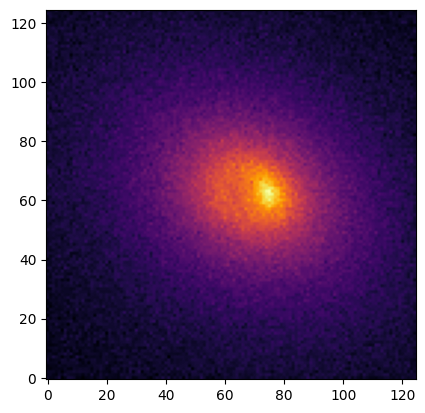

In [21]:
no_ll = lens_sim.simulate((lens_params, [], source_light_params))
p = image_util.add_poisson(no_ll, exp_time=exp_time)
b = image_util.add_background(no_ll,sigma_bkd=background_rms) 
no_ll_noise = no_ll + p + b
plt.imshow(no_ll_noise, origin='lower', cmap='inferno')

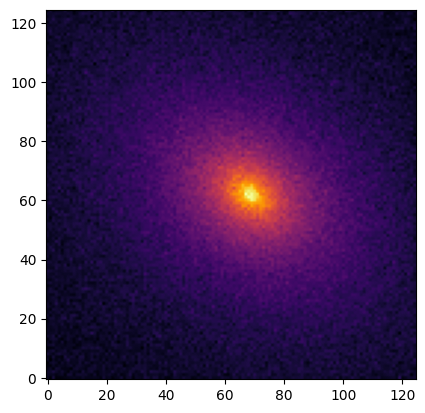

In [22]:
source = lens_sim.simulate(([], [], source_light_params))
p = image_util.add_poisson(source, exp_time=exp_time)
b = image_util.add_background(source,sigma_bkd=background_rms) 
source_noise = source + p + b
plt.imshow(source_noise, origin='lower', cmap='inferno')

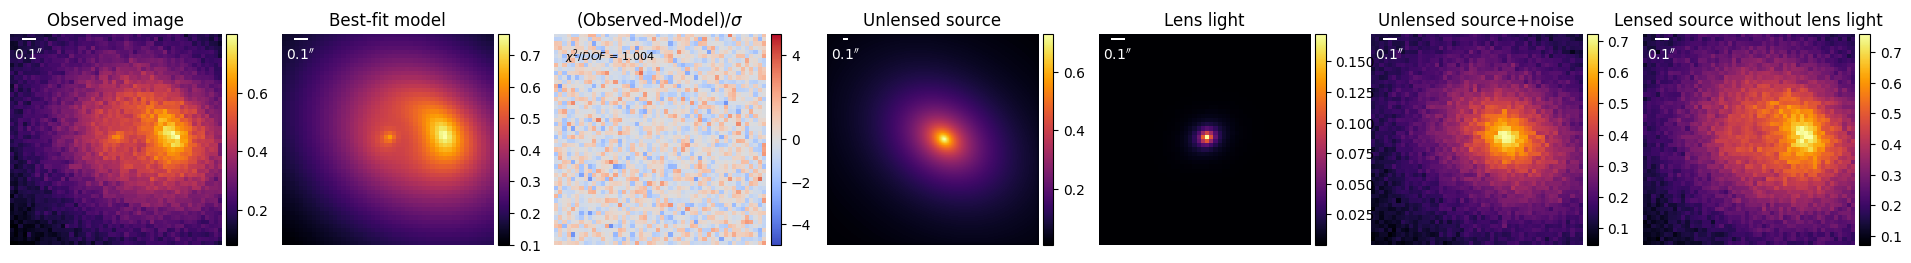

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=7, figsize=(24, 16))  # Increased width for 6 images

# no_ll = lens_sim.simulate((best[0], [], best[2]))
# source = lens_sim.simulate(([], [], best[2]))

scalebar22 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar33 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar44 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar55 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar6 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar7 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
ax[0].add_artist(scalebar22)
ax[1].add_artist(scalebar33)
ax[4].add_artist(scalebar44)
ax[5].add_artist(scalebar55)
ax[6].add_artist(scalebar6)
#ax[7].add_artist(scalebar7)

def add_colorbar(im, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    return fig.colorbar(im, cax=cax)

# Observed/Simulated Image
ax[0].set_title("Observed image")
im1 = ax[0].imshow(observed_img[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im1, ax[0])

# Modeled Image
ax[1].set_title("Best-fit model")
im2 = ax[1].imshow(simulated[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im2, ax[1])

# HMC Residuals
ax[2].set_title(r'(Observed-Model)/$\sigma$')
im3 = ax[2].imshow((resid/err_map)[125//2-25:125//2+25, 125//2-25:125//2+25],
                    cmap='coolwarm', interpolation='none', vmin=-5, vmax=5, origin='lower')
add_colorbar(im3, ax[2])
ax[2].text(2, 42, r'$\chi^2/DOF$ = 1.004', fontsize=8, ha='left', va='bottom')
num_pix = 125
delta_pix = 0.03
ax[3].set_title("Unlensed source")
im5 = ax[3].imshow(source, origin='lower', cmap='inferno')
add_colorbar(im5, ax[3])
# lens_plot.caustics_plot(ax[3], data, lens_model, kwargs_lens,
#                         fast_caustic=False, color_crit='green', color_caustic='green', alpha=0.6)

# scalebar = ScaleBar(1, units="\'\'", dimension="angle",
#                     frameon=False, fixed_value=0.1, color="white", location='upper left')
# ax[3].add_artist(scalebar)

# x_coord = best[2][0]['center_x'].item()
# y_coord = best[2][0]['center_y'].item()
# ax[3].plot(x_coord, y_coord, '*', color='black', label='Source Center')
# #ax[3].legend(fontsize='x-small')
# ax[3].set_xlim(-0.4, 0.4)
# ax[3].set_ylim(-0.4, 0.4)
scalebar = ScaleBar(0.03, units="\'\'", dimension="angle",
                    frameon=False, fixed_value=0.1, color="white", location='upper left')
ax[3].add_artist(scalebar)

ax[5].set_title("Unlensed source+noise")
imx = ax[5].imshow(source_noise[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(imx, ax[5])

# Simulated Lens Light
ax[4].set_title("Lens light")
im5 = ax[4].imshow(lens_sim.simulate(([], best[1], []))[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im5, ax[4])

# Lensed Image W/O Lens Light
# ax[6].set_title("Lensed Source without lens light")
# im6 = ax[6].imshow(no_ll[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
# add_colorbar(im6, ax[6])

ax[6].set_title("Lensed source without lens light")
im7 = ax[6].imshow(no_ll_noise[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im7, ax[6])

# Remove axes borders
for i in ax.ravel():
    i.set_axis_off()

plt.savefig("nfw.png", dpi=300, bbox_inches="tight")
plt.show()

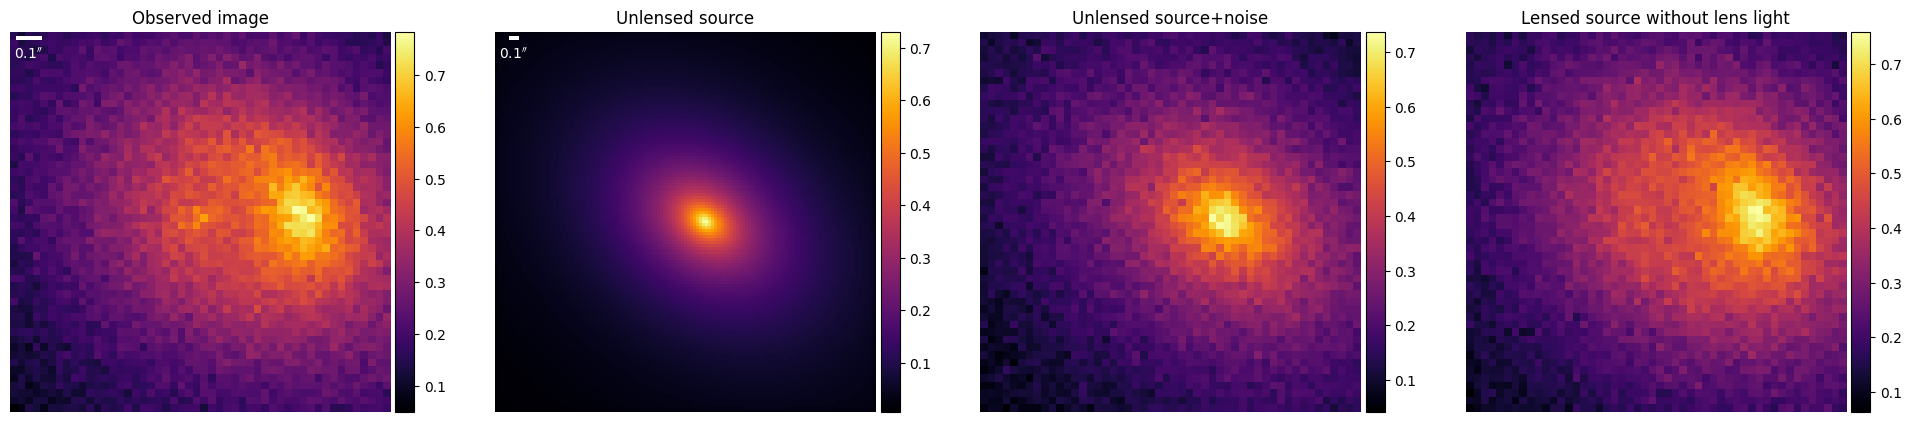

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(24, 16))  # Increased width for 6 images

# no_ll = lens_sim.simulate((best[0], [], best[2]))
# source = lens_sim.simulate(([], [], best[2]))

scalebar22 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar33 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar44 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar55 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar6 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
scalebar7 = ScaleBar(0.03, units="\'\'", dimension="angle",
                     frameon=False, fixed_value=0.1, color="white", location="upper left")
ax[0].add_artist(scalebar22)
ax[1].add_artist(scalebar33)
# ax[4].add_artist(scalebar44)
# ax[5].add_artist(scalebar55)
# ax[6].add_artist(scalebar6)
#ax[7].add_artist(scalebar7)

def add_colorbar(im, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    return fig.colorbar(im, cax=cax)

# Observed/Simulated Image
ax[0].set_title("Observed image")
im1 = ax[0].imshow(observed_img[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im1, ax[0])

# Modeled Image
# ax[1].set_title("Best-fit model")
# im2 = ax[1].imshow(simulated[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
# add_colorbar(im2, ax[1])

# # HMC Residuals
# ax[2].set_title(r'(Observed-Model)/$\sigma$')
# im3 = ax[2].imshow((resid/err_map)[125//2-25:125//2+25, 125//2-25:125//2+25],
#                     cmap='coolwarm', interpolation='none', vmin=-5, vmax=5, origin='lower')
# add_colorbar(im3, ax[2])
# ax[2].text(2, 42, r'$\chi^2/DOF$ = 1.004', fontsize=8, ha='left', va='bottom')
num_pix = 125
delta_pix = 0.03
ax[1].set_title("Unlensed source")
im5 = ax[1].imshow(source, origin='lower', cmap='inferno')
add_colorbar(im5, ax[1])
# lens_plot.caustics_plot(ax[3], data, lens_model, kwargs_lens,
#                         fast_caustic=False, color_crit='green', color_caustic='green', alpha=0.6)

# scalebar = ScaleBar(1, units="\'\'", dimension="angle",
#                     frameon=False, fixed_value=0.1, color="white", location='upper left')
# ax[3].add_artist(scalebar)

# x_coord = best[2][0]['center_x'].item()
# y_coord = best[2][0]['center_y'].item()
# ax[3].plot(x_coord, y_coord, '*', color='black', label='Source Center')
# #ax[3].legend(fontsize='x-small')
# ax[3].set_xlim(-0.4, 0.4)
# ax[3].set_ylim(-0.4, 0.4)
scalebar = ScaleBar(0.03, units="\'\'", dimension="angle",
                    frameon=False, fixed_value=0.1, color="white", location='upper left')
#x[1].add_artist(scalebar)

ax[2].set_title("Unlensed source+noise")
imx = ax[2].imshow(source_noise[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(imx, ax[2])

# Simulated Lens Light
# ax[4].set_title("Lens light")
# im5 = ax[4].imshow(lens_sim.simulate(([], best[1], []))[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
# add_colorbar(im5, ax[4])

# Lensed Image W/O Lens Light
# ax[6].set_title("Lensed Source without lens light")
# im6 = ax[6].imshow(no_ll[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
# add_colorbar(im6, ax[6])

ax[3].set_title("Lensed source without lens light")
im7 = ax[3].imshow(no_ll_noise[125//2-25:125//2+25, 125//2-25:125//2+25], origin='lower', cmap='inferno')
add_colorbar(im7, ax[3])

# Remove axes borders
for i in ax.ravel():
    i.set_axis_off()

plt.savefig("nfw.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
import corner as corner

smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, 21))
smp_physical = prob_model.bij.forward(list(smp.T))
def get_corner_samples(samples, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in samples[0][0].keys():
            return_list.append(samples[0][0][i])
        for j in samples[0][1].keys():
            return_list.append(samples[0][1][j])

    if key == 2:
        for i in samples[1][0].keys():
            return_list.append(samples[1][0][i])

    if key == 3:
        for i in samples[2][0].keys():
            return_list.append(samples[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)
mass_samps.shape

(96000, 7)

In [51]:
lens_light_params = [{'n_sersic': 3, 'e2': 0.2, 'e1': 0.1, 'center_y': 0, 'center_x': 0, 'R_sersic': 0.1, 'Ie': 20}]
source_light_params = [{'n_sersic': 1.5, 'e2': -0.15, 'e1': 0.05, 'center_y': 0, 'center_x': 0.2, 'R_sersic': 1.5, 'Ie': 70}
]
lens_params = [{'r_trunc': 10, 'center_y': 0, 'center_x': 0, 'alpha_Rs': 0.2, 'Rs': 0.7}, {'gamma2': 0.01, 'gamma1': 0.02}]

In [52]:
import corner as corner

smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, 21))
smp_physical = prob_model.bij.forward(list(smp.T))
def get_corner_samples(samples, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in samples[0][0].keys():
            return_list.append(samples[0][0][i])
        for j in samples[0][1].keys():
            return_list.append(samples[0][1][j])

    if key == 2:
        for i in samples[1][0].keys():
            return_list.append(samples[1][0][i])

    if key == 3:
        for i in samples[2][0].keys():
            return_list.append(samples[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)
mass_samps.shape

(96000, 7)

In [53]:
np.median(mass_samps[:, 0])

11.7041235

In [54]:
def get_truth(lens_params, key):
    return_list = []
    if key == 1:
        for i in lens_params[0].keys():
            return_list.append(lens_params[0][i])
        for j in lens_params[1].keys():
            return_list.append(lens_params[1][j])
    if key == 2:
        for i in lens_light_params[0].keys():
            return_list.append(lens_light_params[0][i])
    if key == 3:
        for i in source_light_params[0].keys():
            return_list.append(source_light_params[0][i])
    return np.stack(return_list).T

true_mass = get_truth(lens_params, key=1)
true_mass

array([10.  ,  0.  ,  0.  ,  0.2 ,  0.7 ,  0.01,  0.02])

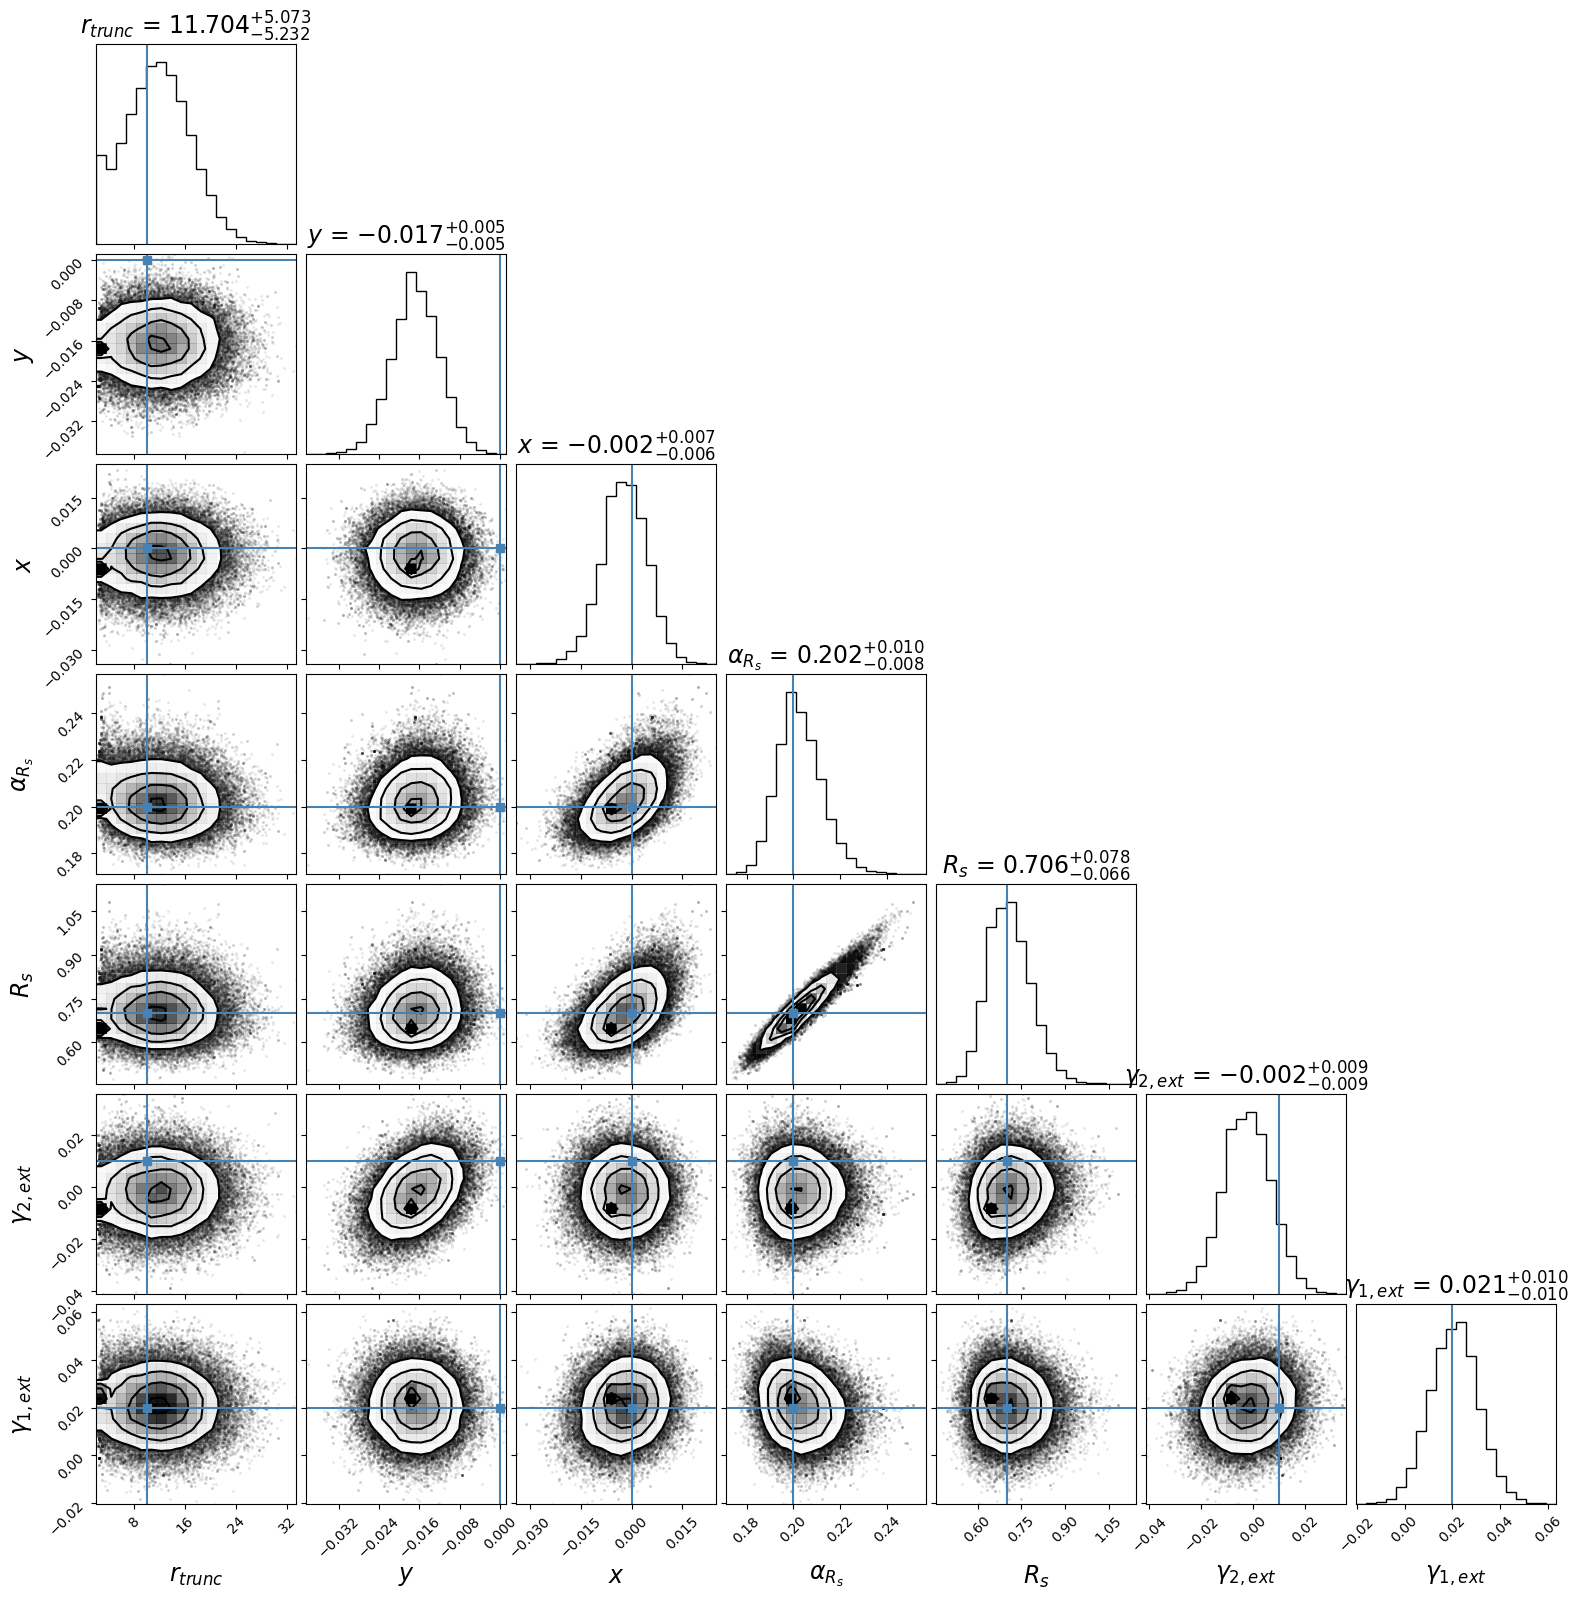

In [55]:
corner.corner(mass_samps,
       show_titles=True, title_fmt='.3f', truths = true_mass, 
       labels=[r'$r_{trunc}$', r'$y$', r'$x$', r'$\alpha_{R_s}$', r'$R_s$', 
               r'$\gamma_{2,ext}$', r'$\gamma_{1,ext}$',
              #  r'$\theta^{sec}_E$', r'$\epsilon^{sec}_1$', r'$\epsilon^{sec}_2$', r'$x^{sec}$', r'$y^{sec}$',
               ], label_kwargs = {'fontsize': 17}, title_kwargs = {'fontsize': 17},);

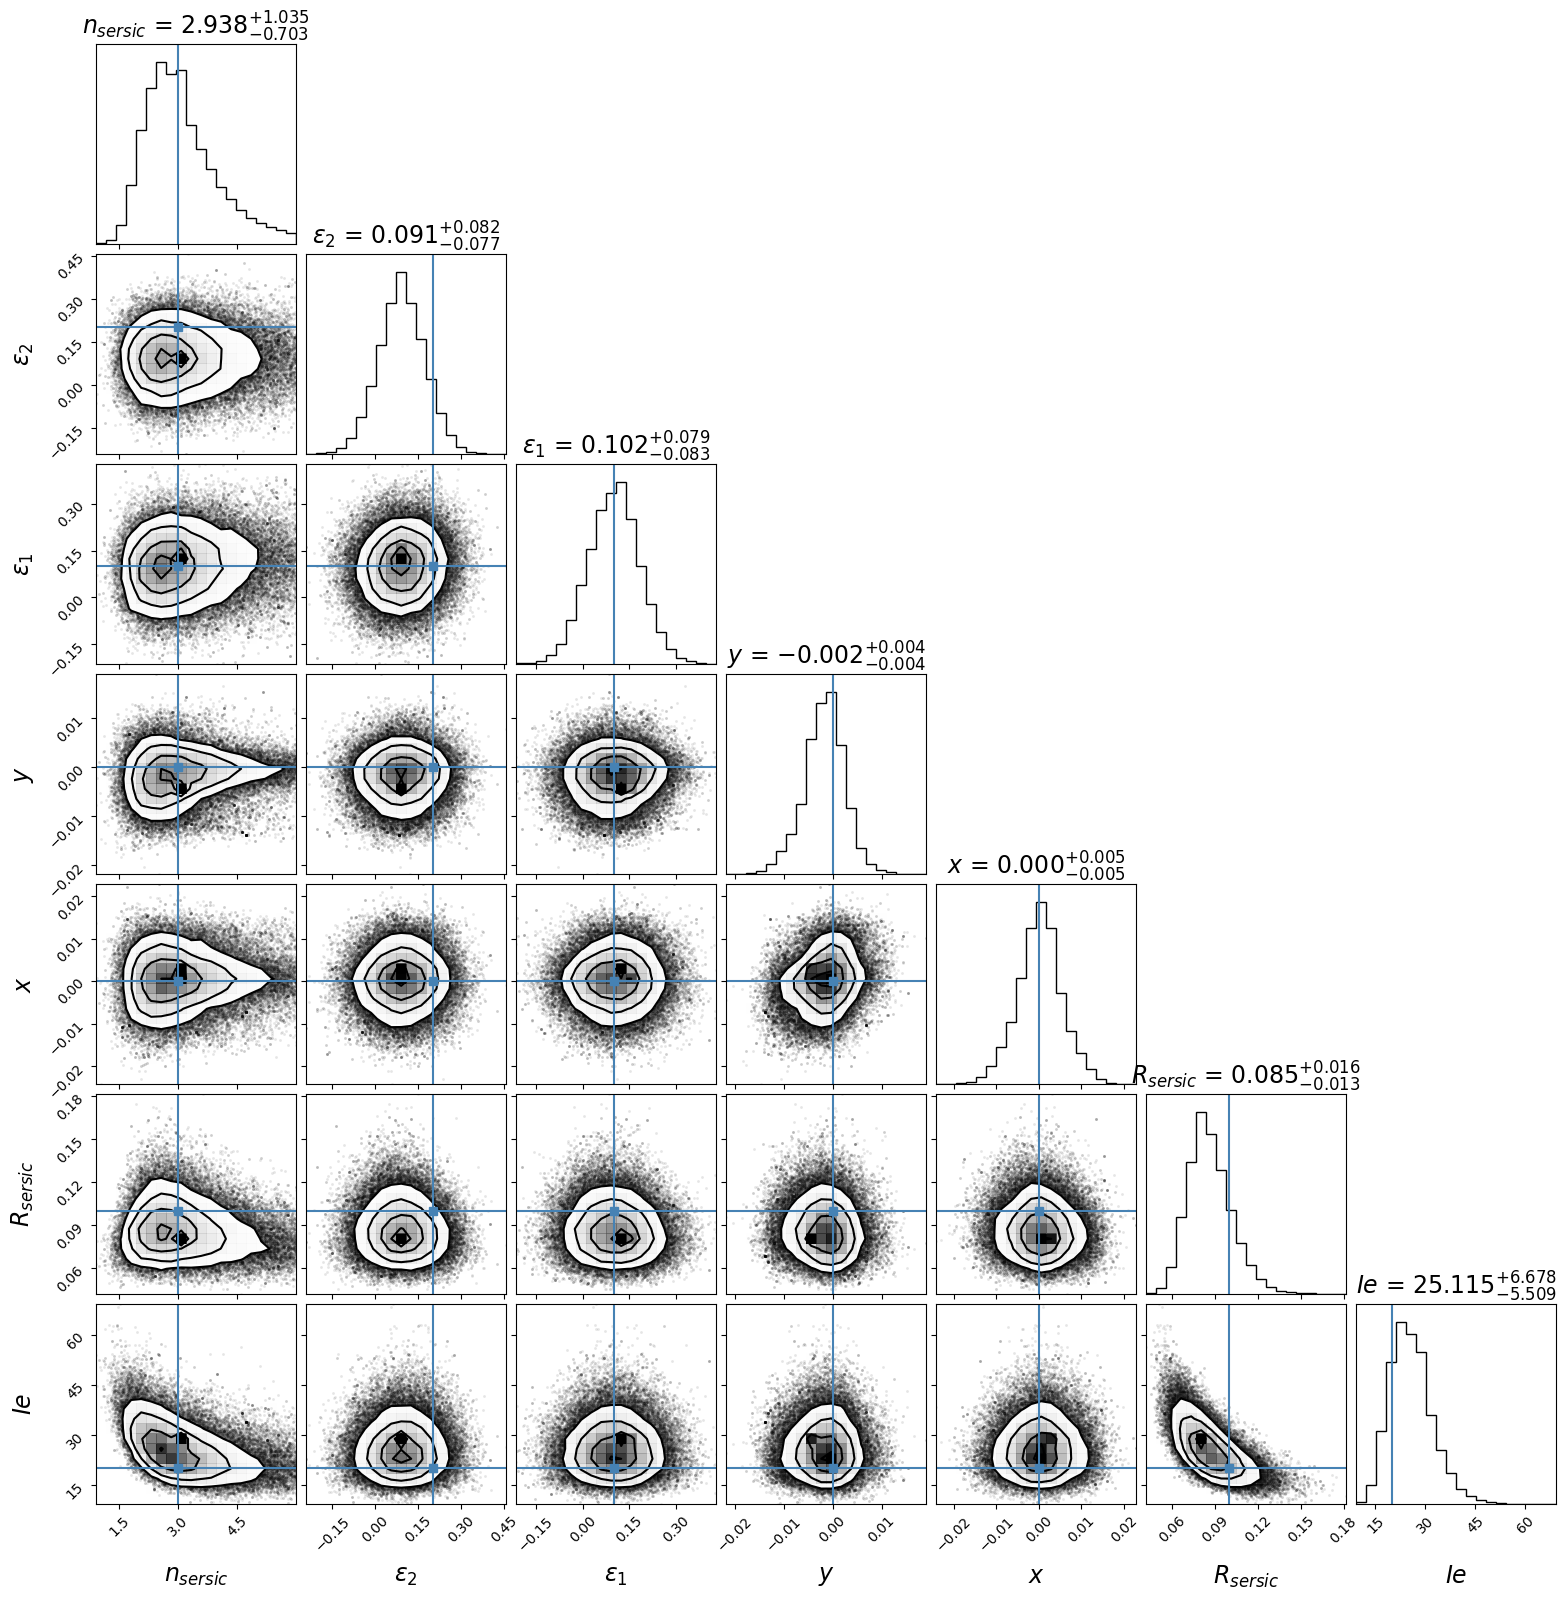

In [56]:
true_ll = get_truth(lens_light_params, key=2)
true_sl = get_truth(source_light_params, key=3)

ll_samps = get_corner_samples(smp_physical, 2)
sl_samps = get_corner_samples(smp_physical, 3)

corner.corner(ll_samps,
       show_titles=True, title_fmt='.3f', truths = true_ll,
       labels=[r'$n_{sersic}$', r'$\epsilon_2$', r'$\epsilon_1$', r'$y$', r'$x$',
               r'$R_{sersic}$', r'$Ie$',
              #  r'$\theta^{sec}_E$', r'$\epsilon^{sec}_1$', r'$\epsilon^{sec}_2$', r'$x^{sec}$', r'$y^{sec}$',
               ], label_kwargs = {'fontsize': 17}, title_kwargs = {'fontsize': 17},);

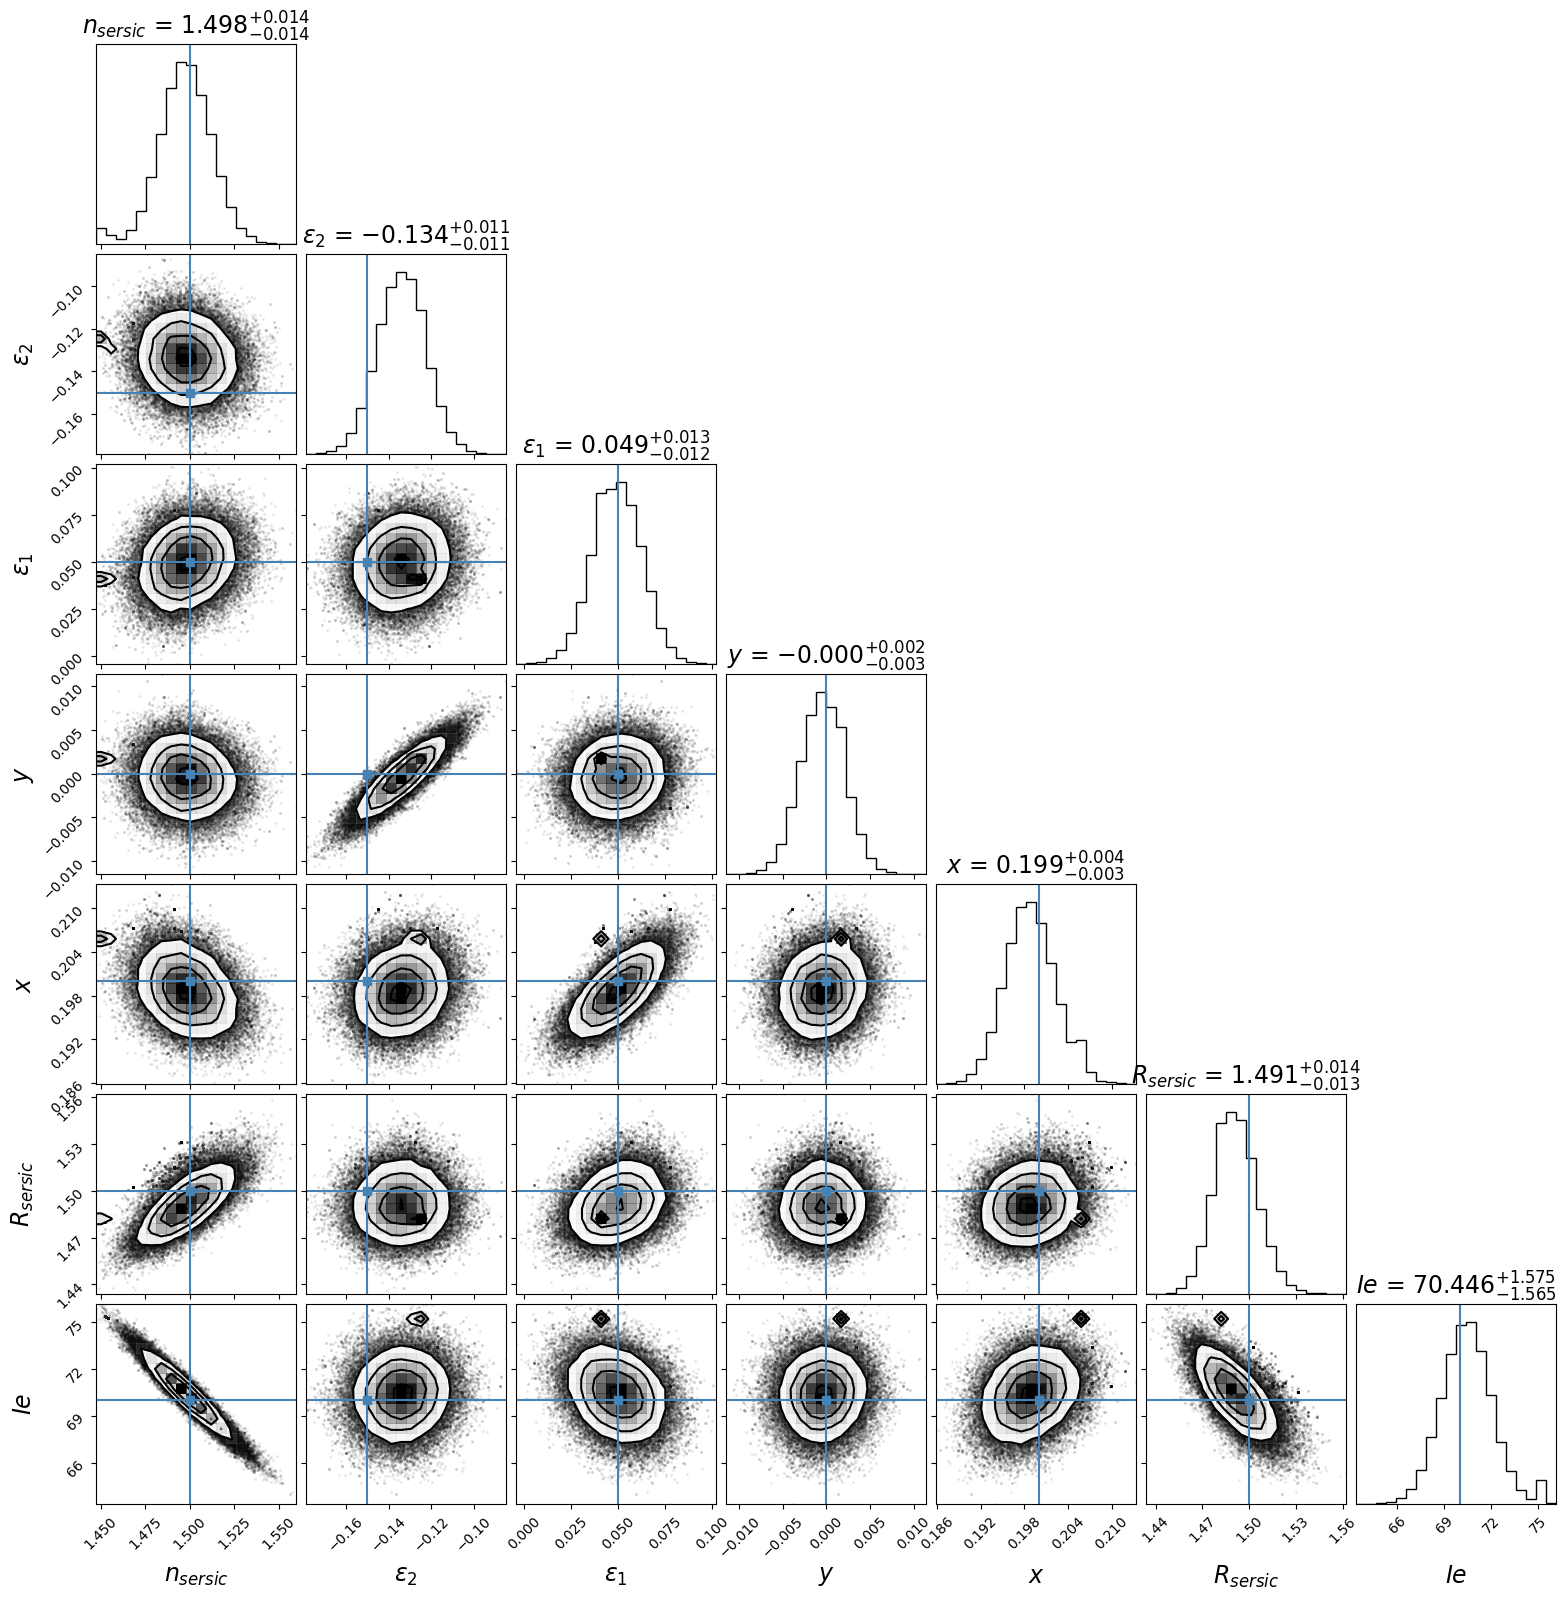

In [42]:
corner.corner(sl_samps,
    show_titles=True, title_fmt='.3f', truths = true_sl,
       labels=[r'$n_{sersic}$', r'$\epsilon_2$', r'$\epsilon_1$', r'$y$', r'$x$',
               r'$R_{sersic}$', r'$Ie$',
              #  r'$\theta^{sec}_E$', r'$\epsilon^{sec}_1$', r'$\epsilon^{sec}_2$', r'$x^{sec}$', r'$y^{sec}$',
               ], label_kwargs = {'fontsize': 17}, title_kwargs = {'fontsize': 17},);